In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/uncleaned_used_cars_eda.csv')

In [ ]:
df.head()


,car_id,brand,model,year,price_inr,km_driven,fuel_type,transmission,owner_type,mileage_kmpl,engine_cc,city,insurance_valid,seller_rating,listed_date
0,CAR001,maruti,Baleno,2009,236000.0,13300,petrol,manual,1st,12.9,1000.0,hyderabad,Yes,3.1,02/02/2026
1,CAR002,MARUTI,i20,2010,292000.0,17600,Diesel,Automatic,Second,13.8,1200.0,Hyd,Yes,3.2,03/03/2026
2,CAR003,Hyundai,Creta,2011,348000.0,21900,diesel,Auto,2nd,14.7,1400.0,Bangalore,Yes,3.3,2026-04-04
3,CAR004,hyundai,Nexon,2012,404000.0,26200,CNG,AUTOMATIC,Third,15.6,1600.0,Bengaluru,NO,3.4,05/05/2026
4,CAR005,Tata,XUV300,2013,460000.0,30500,Electric,Manual,3rd,16.5,1800.0,Mumbai,Yes,3.5,06/06/2026


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 123 entries, 0 to 122
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   car_id           123 non-null    object 
 1   brand            116 non-null    object 
 2   model            123 non-null    object 
 3   year             123 non-null    object 
 4   price_inr        118 non-null    float64
 5   km_driven        123 non-null    object 
 6   fuel_type        123 non-null    object 
 7   transmission     120 non-null    object 
 8   owner_type       123 non-null    object 
 9   mileage_kmpl     118 non-null    float64
 10  engine_cc        119 non-null    float64
 11  city             123 non-null    object 
 12  insurance_valid  123 non-null    object 
 13  seller_rating    123 non-null    float64
 14  listed_date      123 non-null    object 
dtypes: float64(4), object(11)
memory usage: 14.5+ KB


In [ ]:
df.describe()

,price_inr,mileage_kmpl,engine_cc,seller_rating
count,1.180000e+02,118.000000,119.000000,123.000000
mean,7.984492e+05,16.118644,1507.563025,4.204065
std,8.676712e+05,2.613769,456.805352,1.091127
min,1.890000e+05,12.000000,800.000000,3.000000
25%,4.532500e+05,13.800000,1200.000000,3.600000
50%,7.285000e+05,16.500000,1600.000000,4.100000
75%,9.852500e+05,18.300000,1900.000000,4.550000
max,9.500000e+06,20.100000,2200.000000,8.700000


In [ ]:
#missing values
df.isnull().sum()

,0
car_id,0
brand,7
model,0
year,0
price_inr,5
km_driven,0
fuel_type,0
transmission,3
owner_type,0
mileage_kmpl,5


In [ ]:
#duplicate values
df.duplicated().sum()

np.int64(3)

In [ ]:
#Removal of duplicate values
df.drop_duplicates(inplace=True)


In [ ]:
# Recheck
df.duplicated().sum()

np.int64(0)

In [ ]:
# Missing Value  Treatment
#if the datatype of column is "object" , replace with "Mode"
#if the datatype of column is float/ int, replace with "mean/ median"

In [ ]:
df["brand"] = df["brand"].fillna(df["brand"].mode()[0])

In [ ]:
df["price_inr"] = df["price_inr"].fillna(df["price_inr"].median())

In [ ]:
df["transmission"] = df["transmission"].fillna(df["transmission"].mode()[0])

In [ ]:
df["mileage_kmpl"] = df["mileage_kmpl"].fillna(df["mileage_kmpl"].median())

In [ ]:
df["engine_cc"] = df["engine_cc"].fillna(df["engine_cc"].median())

In [ ]:
df.isnull().sum()

,0
car_id,0
brand,0
model,0
year,0
price_inr,0
km_driven,0
fuel_type,0
transmission,0
owner_type,0
mileage_kmpl,0


In [ ]:
# analysis
# univariate analysis
df["brand"].value_counts()

,count
brand,
Hyundai,16
maruti,10
Kia,10
Tata,10
Maruti,10
Toyota,10
hyundai,9
MARUTI,9
Mahindra,9


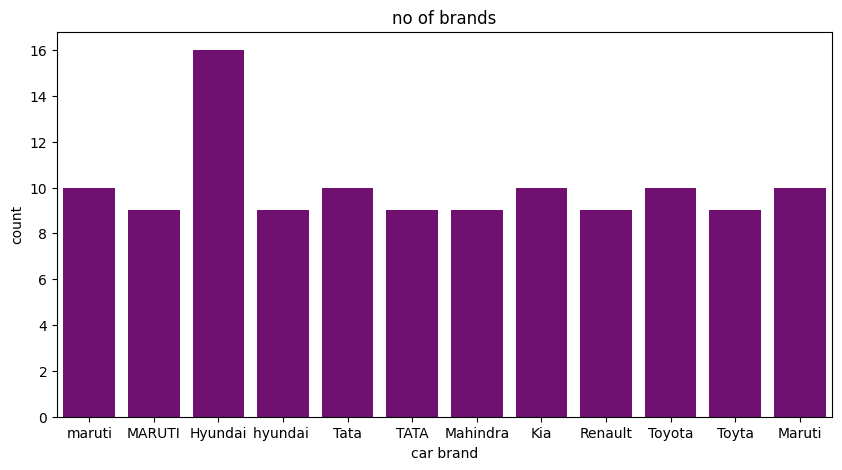

In [ ]:
plt.figure(figsize = (10,5))
sns.countplot(data = df, x = "brand", color = "purple")
plt.title("no of brands")
plt.xlabel("car brand")
plt.ylabel("count")
plt.show()

In [ ]:
# first standardize the letter case
df["brand"] = df["brand"].str.strip().str.lower()

In [ ]:
df["brand"].value_counts()

,count
brand,
maruti,29
hyundai,25
tata,19
kia,10
toyota,10
mahindra,9
renault,9
toyta,9


In [ ]:
df["brand"] = df["brand"].replace({"toyta":"toyota"})

In [ ]:
df["brand"].value_counts()

,count
brand,
maruti,29
hyundai,25
tata,19
toyota,19
kia,10
mahindra,9
renault,9


In [ ]:
df["brand"] = df["brand"].replace({"Toyota":"toyota"})

In [ ]:
df["brand"].value_counts()

,count
brand,
maruti,29
hyundai,25
tata,19
toyota,19
kia,10
mahindra,9
renault,9


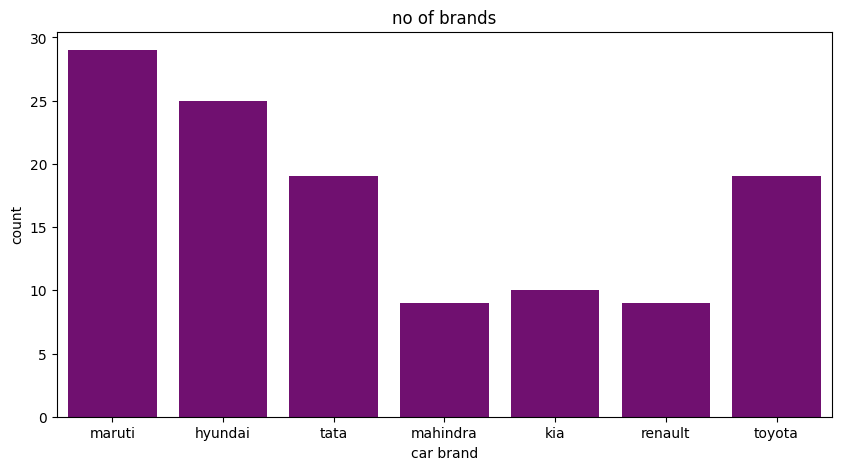

In [ ]:
plt.figure(figsize = (10,5))
sns.countplot(data = df, x = "brand", color = "purple")
plt.title("no of brands")
plt.xlabel("car brand")
plt.ylabel("count")
plt.show()

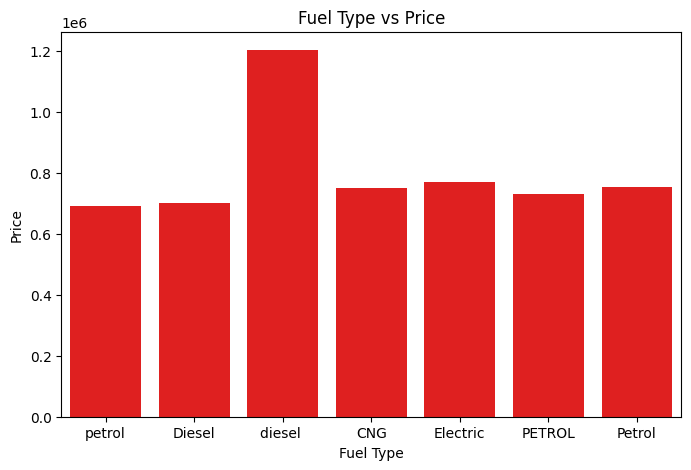

In [ ]:
#Bivariate Analysis

plt.figure(figsize = (8,5))
sns.barplot(data = df, x = "fuel_type",y = "price_inr",color = "red",errorbar = None)
plt.title("Fuel Type vs Price")
plt.xlabel("Fuel Type")
plt.ylabel("Price")
plt.show()



In [ ]:
df["fuel_type"] = df["fuel_type"].str.strip().str.lower()
print(df["fuel_type"].value_counts())

fuel_type
petrol      52
diesel      34
cng         17
electric    17
Name: count, dtype: int64


In [ ]:
categorical_columns = df.select_dtypes(include = "object").columns
print(categorical_columns)

Index(['car_id', 'brand', 'model', 'year', 'km_driven', 'fuel_type',
       'transmission', 'owner_type', 'city', 'insurance_valid', 'listed_date'],
      dtype='object')


In [ ]:
for column in categorical_columns:
  print(column,":",
df[column].nunique(dropna = False),
df[column].unique(),sep = "\n")

car_id
:
120
['CAR001' 'CAR002' 'CAR003' 'CAR004' 'CAR005' 'CAR006' 'CAR007' 'CAR008'
 'CAR009' 'CAR010' 'CAR011' 'CAR012' 'CAR013' 'CAR014' 'CAR015' 'CAR016'
 'CAR017' 'CAR018' 'CAR019' 'CAR020' 'CAR021' 'CAR022' 'CAR023' 'CAR024'
 'CAR025' 'CAR026' 'CAR027' 'CAR028' 'CAR029' 'CAR030' 'CAR031' 'CAR032'
 'CAR033' 'CAR034' 'CAR035' 'CAR036' 'CAR037' 'CAR038' 'CAR039' 'CAR040'
 'CAR041' 'CAR042' 'CAR043' 'CAR044' 'CAR045' 'CAR046' 'CAR047' 'CAR048'
 'CAR049' 'CAR050' 'CAR051' 'CAR052' 'CAR053' 'CAR054' 'CAR055' 'CAR056'
 'CAR057' 'CAR058' 'CAR059' 'CAR060' 'CAR061' 'CAR062' 'CAR063' 'CAR064'
 'CAR065' 'CAR066' 'CAR067' 'CAR068' 'CAR069' 'CAR070' 'CAR071' 'CAR072'
 'CAR073' 'CAR074' 'CAR075' 'CAR076' 'CAR077' 'CAR078' 'CAR079' 'CAR080'
 'CAR081' 'CAR082' 'CAR083' 'CAR084' 'CAR085' 'CAR086' 'CAR087' 'CAR088'
 'CAR089' 'CAR090' 'CAR091' 'CAR092' 'CAR093' 'CAR094' 'CAR095' 'CAR096'
 'CAR097' 'CAR098' 'CAR099' 'CAR100' 'CAR101' 'CAR102' 'CAR103' 'CAR104'
 'CAR105' 'CAR106' 'CAR107' 'CAR108' '

In [ ]:
#cleaning categorical variable
df_clean = df.copy()


In [ ]:
text_columns = df_clean.select_dtypes(include = "object").columns
for column in text_columns:
  df_clean[column] = df_clean[column].str.strip().str.lower()


In [ ]:
df_clean.head()

,car_id,brand,model,year,price_inr,km_driven,fuel_type,transmission,owner_type,mileage_kmpl,engine_cc,city,insurance_valid,seller_rating,listed_date
0,car001,maruti,baleno,2009,236000.0,13300,petrol,manual,1st,12.9,1000.0,hyderabad,yes,3.1,02/02/2026
1,car002,maruti,i20,2010,292000.0,17600,diesel,automatic,second,13.8,1200.0,hyd,yes,3.2,03/03/2026
2,car003,hyundai,creta,2011,348000.0,21900,diesel,auto,2nd,14.7,1400.0,bangalore,yes,3.3,2026-04-04
3,car004,hyundai,nexon,2012,404000.0,26200,cng,automatic,third,15.6,1600.0,bengaluru,no,3.4,05/05/2026
4,car005,tata,xuv300,2013,460000.0,30500,electric,manual,3rd,16.5,1800.0,mumbai,yes,3.5,06/06/2026


In [ ]:
df_clean["transmission"].value_counts()

,count
transmission,
automatic,50
manual,47
auto,23


In [ ]:
df_clean["owner_type"].value_counts()

,count
owner_type,
1st,20
second,20
2nd,20
third,20
3rd,20
first,20


In [ ]:
df_clean["city"].value_counts()


,count
city,
hyderabad,24
hyd,12
bangalore,12
bengaluru,12
mumbai,12
pune,12
chennai,12
delhi,12
new delhi,12


In [ ]:
# Standardize the categorical columns
df_clean["transmission"] = (df_clean["transmission"].str.lower().replace({"auto":"automatic"}))
df_clean["owner_type"] = (df_clean["owner_type"].str.lower().replace({"1st":"first", "2nd":"second","3rd":"third"}))
df_clean["city"] = (df_clean["city"].replace({"new delhi":"delhi","hydeabad":"hyderabad","bengaluru":"bangalore"}))

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120 entries, 0 to 119
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   car_id           120 non-null    object 
 1   brand            120 non-null    object 
 2   model            120 non-null    object 
 3   year             120 non-null    object 
 4   price_inr        120 non-null    float64
 5   km_driven        120 non-null    object 
 6   fuel_type        120 non-null    object 
 7   transmission     120 non-null    object 
 8   owner_type       120 non-null    object 
 9   mileage_kmpl     120 non-null    float64
 10  engine_cc        120 non-null    float64
 11  city             120 non-null    object 
 12  insurance_valid  120 non-null    object 
 13  seller_rating    120 non-null    float64
 14  listed_date      120 non-null    object 
dtypes: float64(4), object(11)
memory usage: 15.0+ KB


In [ ]:
# Remove column names(unwanted)
df_clean.drop(columns = ["car_id","listed_date"],inplace = True)

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 120 entries, 0 to 119
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   brand            120 non-null    object 
 1   model            120 non-null    object 
 2   year             120 non-null    object 
 3   price_inr        120 non-null    float64
 4   km_driven        120 non-null    object 
 5   fuel_type        120 non-null    object 
 6   transmission     120 non-null    object 
 7   owner_type       120 non-null    object 
 8   mileage_kmpl     120 non-null    float64
 9   engine_cc        120 non-null    float64
 10  city             120 non-null    object 
 11  insurance_valid  120 non-null    object 
 12  seller_rating    120 non-null    float64
dtypes: float64(4), object(9)
memory usage: 13.1+ KB


In [ ]:
# converting datatype
df_clean["km_driven"] = (df_clean["km_driven"].astype(str).str.replace("km","", case = False, regex = False).str.strip())

In [ ]:
# convert object into numerical datatypes
df_clean["km_driven"] = pd.to_numeric(df_clean["km_driven"])

In [ ]:
df_clean["year"] = pd.to_numeric(df_clean["year"],errors = "coerce")

In [ ]:
df_clean["km_driven"].value_counts()

,count
km_driven,
13300,4
17600,4
21900,4
26200,4
30500,4
34800,4
39100,4
43400,4
47700,4


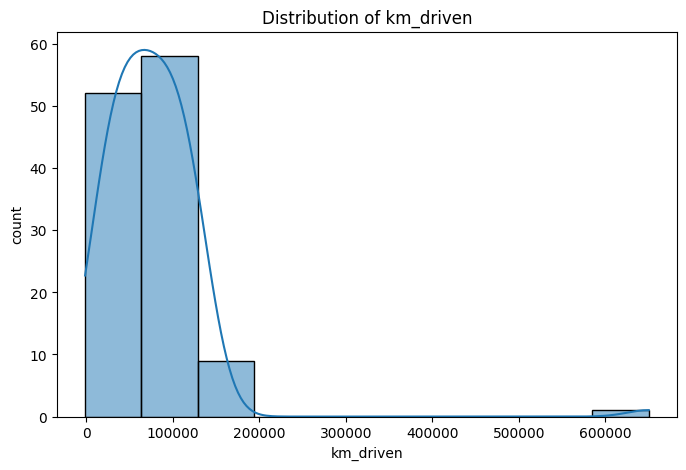

In [ ]:
plt.figure(figsize = (8,5))
sns.histplot(data = df_clean, x = "km_driven", bins = 10, kde = True)
plt.title("Distribution of km_driven")
plt.xlabel("km_driven")
plt.ylabel("count")
plt.show()

In [ ]:
numeric_df_clean = df_clean.select_dtypes(include = "number")

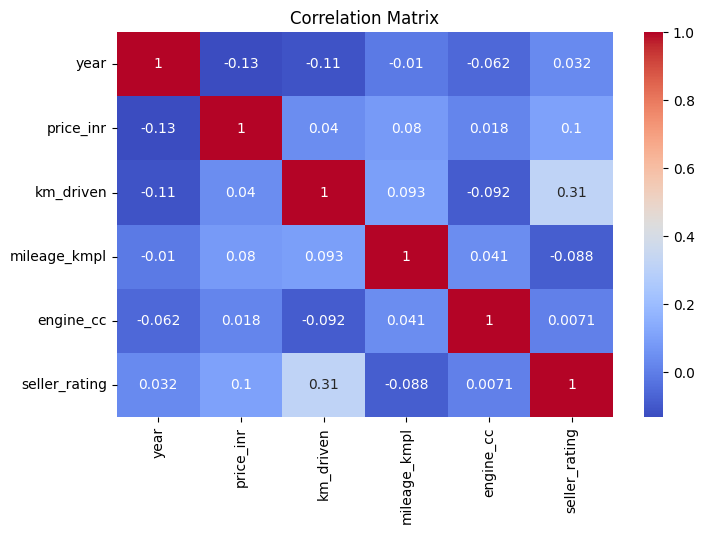

In [ ]:
# multivariate analysis
plt.figure(figsize = (8,5))
sns.heatmap(numeric_df_clean.corr(), annot = True, cmap = "coolwarm")
plt.title("Correlation Matrix")
plt.show()

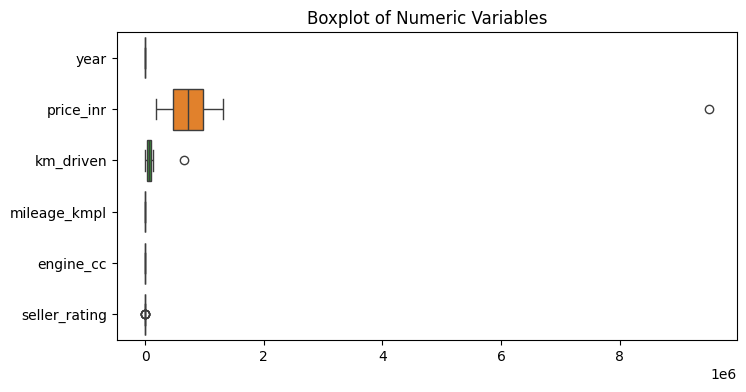

In [ ]:
# Outlier
plt.figure(figsize = (8,4))
sns.boxplot(data = numeric_df_clean, orient = "h")
plt.title("Boxplot of Numeric Variables")
plt.show()


In [ ]:
#outlier removal
for i in numeric_df_clean:
  Q1 = df_clean[i].quantile(0.25)
  Q3 = df_clean[i].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  df_clean = df_clean[(df_clean[i] >= lower_bound) & (df_clean[i] <= upper_bound)]

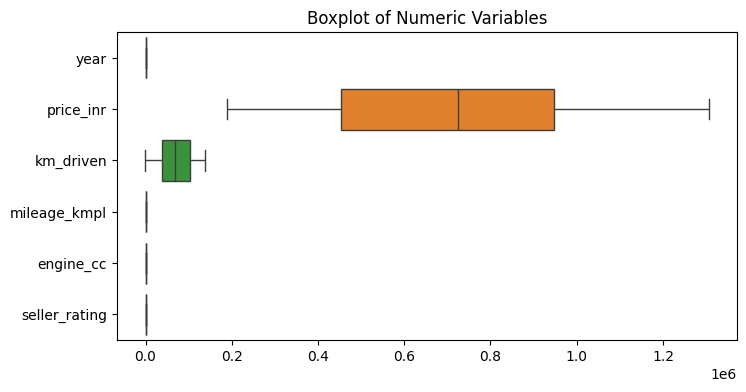

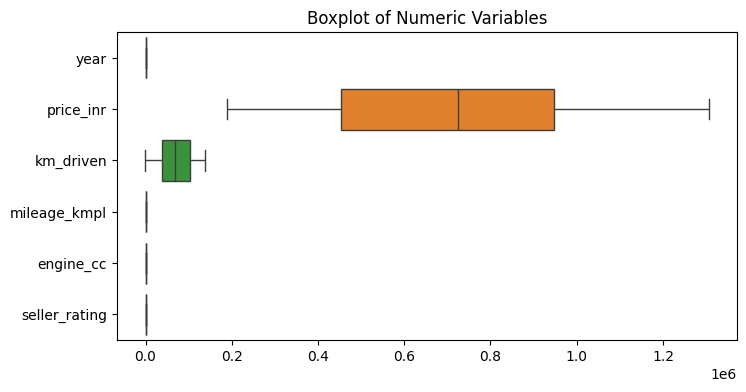

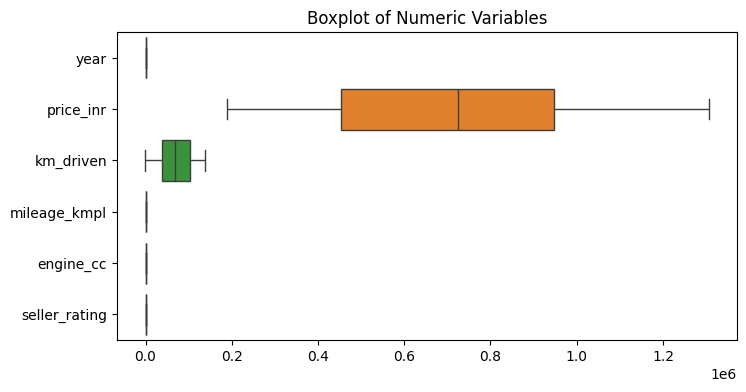

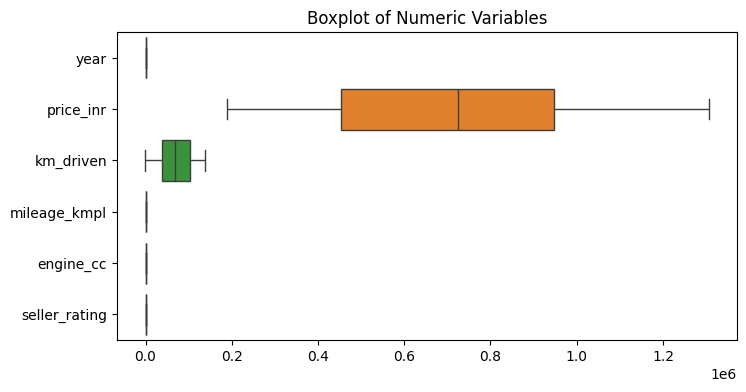

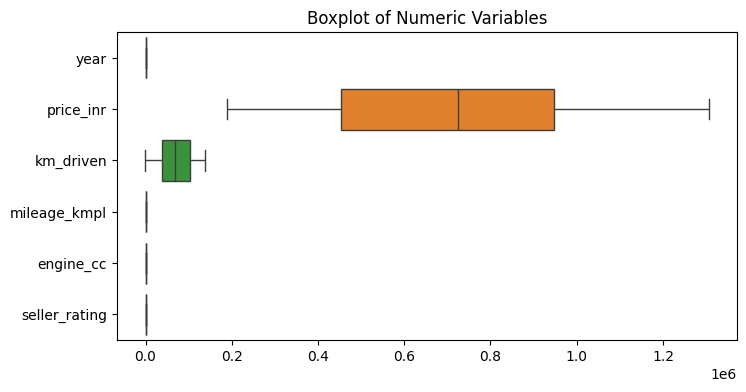

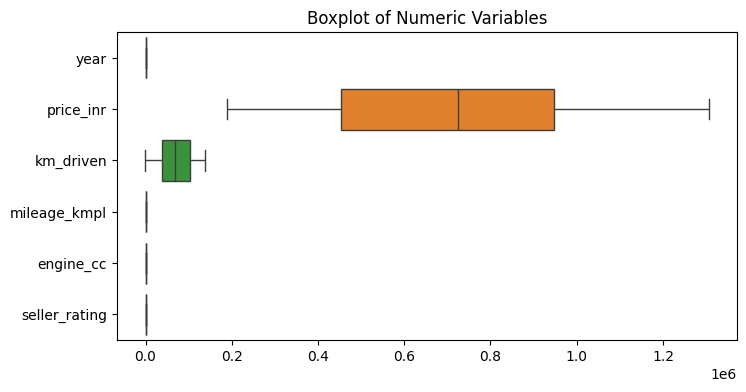

In [ ]:
# rechecking on outlier

# Reset the index

df_clean = df_clean.reset_index(drop=True)

# select updated numerical columns

numeric_df_clean = df_clean.select_dtypes(include = np.number)

for i in numeric_df_clean.columns:

  plt.figure(figsize = (8,4))

  sns.boxplot(data = numeric_df_clean, orient = "h")

  plt.title("Boxplot of Numeric Variables")

  plt.show()






In [ ]:
from pandas.core.indexes.api import Index
categorical_columns = df_clean.select_dtypes(include = "object").columns
print(categorical_columns)

Index(['brand', 'model', 'fuel_type', 'transmission', 'owner_type', 'city', 'insurance_valid'], dtype = 'object')

Index(['brand', 'model', 'fuel_type', 'transmission', 'owner_type', 'city',
       'insurance_valid'],
      dtype='object')


Index(['brand', 'model', 'fuel_type', 'transmission', 'owner_type', 'city',
       'insurance_valid'],
      dtype='object')

In [ ]:
# one -hot encoding

df_encoded = pd.get_dummies(df_clean, columns = categorical_columns, drop_first = True,dtype = int)






In [ ]:
print(df_encoded.dtypes)

df_encoded.head()






year                   float64
price_inr              float64
km_driven                int64
mileage_kmpl           float64
engine_cc              float64
seller_rating          float64
brand_kia                int64
brand_mahindra           int64
brand_maruti             int64
brand_renault            int64
brand_tata               int64
brand_toyota             int64
model_baleno             int64
model_creta              int64
model_i20                int64
model_innova             int64
model_kwid               int64
model_nexon              int64
model_seltos             int64
model_swift              int64
model_xuv300             int64
fuel_type_diesel         int64
fuel_type_electric       int64
fuel_type_petrol         int64
transmission_manual      int64
owner_type_second        int64
owner_type_third         int64
city_chennai             int64
city_delhi               int64
city_hyd                 int64
city_hyderabad           int64
city_mumbai              int64
city_pun

,year,price_inr,km_driven,mileage_kmpl,engine_cc,seller_rating,brand_kia,brand_mahindra,brand_maruti,brand_renault,...,transmission_manual,owner_type_second,owner_type_third,city_chennai,city_delhi,city_hyd,city_hyderabad,city_mumbai,city_pune,insurance_valid_yes
0,2009.0,236000.0,13300,12.9,1000.0,3.1,0,0,1,0,...,1,0,0,0,0,0,1,0,0,1
1,2010.0,292000.0,17600,13.8,1200.0,3.2,0,0,1,0,...,0,1,0,0,0,1,0,0,0,1
2,2011.0,348000.0,21900,14.7,1400.0,3.3,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
3,2012.0,404000.0,26200,15.6,1600.0,3.4,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,2013.0,460000.0,30500,16.5,1800.0,3.5,0,0,0,0,...,1,0,1,0,0,0,0,1,0,1


In [ ]:
# changing float to int
df_encoded["price_inr"] = df_encoded["price_inr"].astype(int)
df_encoded["km_driven"] = df_encoded["km_driven"].astype(int)
df_encoded["year"] = df_encoded["year"].astype(int)
df_encoded["mileage_kmpl"] = df_encoded["mileage_kmpl"].astype(int)
df_encoded["engine_cc"] = df_encoded["engine_cc"].astype(int)
df_encoded["seller_rating"] = df_encoded["seller_rating"].astype(int)

In [ ]:
print(df_encoded.dtypes)
df_encoded.head()


year                   int64
price_inr              int64
km_driven              int64
mileage_kmpl           int64
engine_cc              int64
seller_rating          int64
brand_kia              int64
brand_mahindra         int64
brand_maruti           int64
brand_renault          int64
brand_tata             int64
brand_toyota           int64
model_baleno           int64
model_creta            int64
model_i20              int64
model_innova           int64
model_kwid             int64
model_nexon            int64
model_seltos           int64
model_swift            int64
model_xuv300           int64
fuel_type_diesel       int64
fuel_type_electric     int64
fuel_type_petrol       int64
transmission_manual    int64
owner_type_second      int64
owner_type_third       int64
city_chennai           int64
city_delhi             int64
city_hyd               int64
city_hyderabad         int64
city_mumbai            int64
city_pune              int64
insurance_valid_yes    int64
dtype: object


,year,price_inr,km_driven,mileage_kmpl,engine_cc,seller_rating,brand_kia,brand_mahindra,brand_maruti,brand_renault,...,transmission_manual,owner_type_second,owner_type_third,city_chennai,city_delhi,city_hyd,city_hyderabad,city_mumbai,city_pune,insurance_valid_yes
0,2009,236000,13300,12,1000,3,0,0,1,0,...,1,0,0,0,0,0,1,0,0,1
1,2010,292000,17600,13,1200,3,0,0,1,0,...,0,1,0,0,0,1,0,0,0,1
2,2011,348000,21900,14,1400,3,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
3,2012,404000,26200,15,1600,3,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
4,2013,460000,30500,16,1800,3,0,0,0,0,...,1,0,1,0,0,0,0,1,0,1
